# PerfX SDK Overhead Analysis
Compares CPU usage, memory, and startup time between **withSdk** and **noSdk** Cheddar builds.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# measure_overhead.sh writes here directly. We re-run the same script and the
# CSV gets overwritten on top, so no per-device sub-folder is needed.
RESULTS = '../overhead/results'

## 1. Load data

In [29]:
with_sdk = pd.read_csv(f'{RESULTS}/withSdk.csv')
no_sdk   = pd.read_csv(f'{RESULTS}/noSdk.csv')
with_fb  = pd.read_csv(f'{RESULTS}/withFirebase.csv')
with_dd  = pd.read_csv(f'{RESULTS}/withDatadog.csv')

startup_with = pd.read_csv(f'{RESULTS}/withSdk_startup.txt').squeeze()
startup_no   = pd.read_csv(f'{RESULTS}/noSdk_startup.txt').squeeze()
startup_fb   = pd.read_csv(f'{RESULTS}/withFirebase_startup.txt').squeeze()
startup_dd   = pd.read_csv(f'{RESULTS}/withDatadog_startup.txt').squeeze()

# Convert PSS and Java heap from KB to MB
for df in [with_sdk, no_sdk, with_fb, with_dd]:
    df['pss_mb']       = df['pss_kb'] / 1024
    df['java_heap_mb'] = df['java_heap_kb'] / 1024

print('noSdk        samples:', len(no_sdk))
print('withSdk      samples:', len(with_sdk))
print('withFirebase samples:', len(with_fb))
print('withDatadog  samples:', len(with_dd))
with_sdk.head()

noSdk        samples: 90
withSdk      samples: 90
withFirebase samples: 90
withDatadog  samples: 90


,timestamp_s,cpu_pct,pss_kb,java_heap_kb,pss_mb,java_heap_mb
0,1,327.83,196631,257072,192.022461,251.046875
1,2,81.58,177499,256428,173.338867,250.417969
2,3,39.67,173243,257084,169.182617,251.058594
3,4,93.91,173331,257336,169.268555,251.304688
4,5,68.42,174343,258468,170.256836,252.410156


## 2. Summary table

In [ ]:
def overhead(other_val, base_val, unit=''):
    delta = other_val - base_val
    pct   = delta / base_val * 100 if base_val != 0 else float('nan')
    return f'+{delta:.2f}{unit} (+{pct:.1f}%)' if delta >= 0 else f'{delta:.2f}{unit} ({pct:.1f}%)'

rows = [
    ('Cold startup time (ms)',
     f'{startup_no.mean():.1f}',
     f'{startup_with.mean():.1f}',
     f'{startup_fb.mean():.1f}',
     f'{startup_dd.mean():.1f}',
     overhead(startup_with.mean(), startup_no.mean(), ' ms'),
     overhead(startup_fb.mean(),   startup_no.mean(), ' ms'),
     overhead(startup_dd.mean(),   startup_no.mean(), ' ms')),

    ('Avg CPU usage (%)',
     f'{no_sdk.cpu_pct.mean():.2f}',
     f'{with_sdk.cpu_pct.mean():.2f}',
     f'{with_fb.cpu_pct.mean():.2f}',
     f'{with_dd.cpu_pct.mean():.2f}',
     overhead(with_sdk.cpu_pct.mean(), no_sdk.cpu_pct.mean(), '%'),
     overhead(with_fb.cpu_pct.mean(),  no_sdk.cpu_pct.mean(), '%'),
     overhead(with_dd.cpu_pct.mean(),  no_sdk.cpu_pct.mean(), '%')),

    ('Avg PSS memory (MB)',
     f'{no_sdk.pss_mb.mean():.1f}',
     f'{with_sdk.pss_mb.mean():.1f}',
     f'{with_fb.pss_mb.mean():.1f}',
     f'{with_dd.pss_mb.mean():.1f}',
     overhead(with_sdk.pss_mb.mean(), no_sdk.pss_mb.mean(), ' MB'),
     overhead(with_fb.pss_mb.mean(),  no_sdk.pss_mb.mean(), ' MB'),
     overhead(with_dd.pss_mb.mean(),  no_sdk.pss_mb.mean(), ' MB')),

    ('Avg Java heap (MB)',
     f'{no_sdk.java_heap_mb.mean():.1f}',
     f'{with_sdk.java_heap_mb.mean():.1f}',
     f'{with_fb.java_heap_mb.mean():.1f}',
     f'{with_dd.java_heap_mb.mean():.1f}',
     overhead(with_sdk.java_heap_mb.mean(), no_sdk.java_heap_mb.mean(), ' MB'),
     overhead(with_fb.java_heap_mb.mean(),  no_sdk.java_heap_mb.mean(), ' MB'),
     overhead(with_dd.java_heap_mb.mean(),  no_sdk.java_heap_mb.mean(), ' MB')),
]

summary = pd.DataFrame(rows, columns=[
    'Metric', 'Baseline', 'PerfX', 'Firebase', 'Datadog',
    'PerfX overhead', 'Firebase overhead', 'Datadog overhead',
])
summary

## 3. CPU usage over time

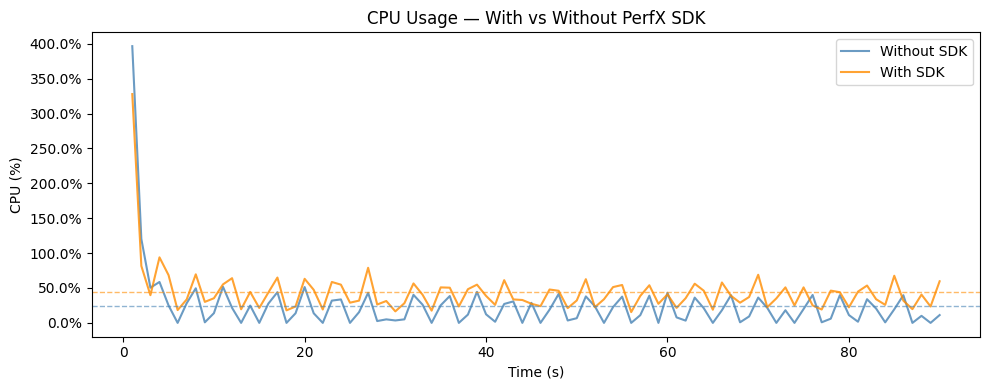

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(no_sdk.timestamp_s,   no_sdk.cpu_pct,   label='Without SDK', color='steelblue',  alpha=0.8)
ax.plot(with_sdk.timestamp_s, with_sdk.cpu_pct, label='With SDK',    color='darkorange', alpha=0.8)

ax.axhline(no_sdk.cpu_pct.mean(),   color='steelblue',  linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(with_sdk.cpu_pct.mean(), color='darkorange', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('Time (s)')
ax.set_ylabel('CPU (%)')
ax.set_title('CPU Usage — With vs Without PerfX SDK')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.savefig(f'{RESULTS}/cpu_overhead.png', dpi=150)
plt.show()

## 4. Memory (PSS) over time

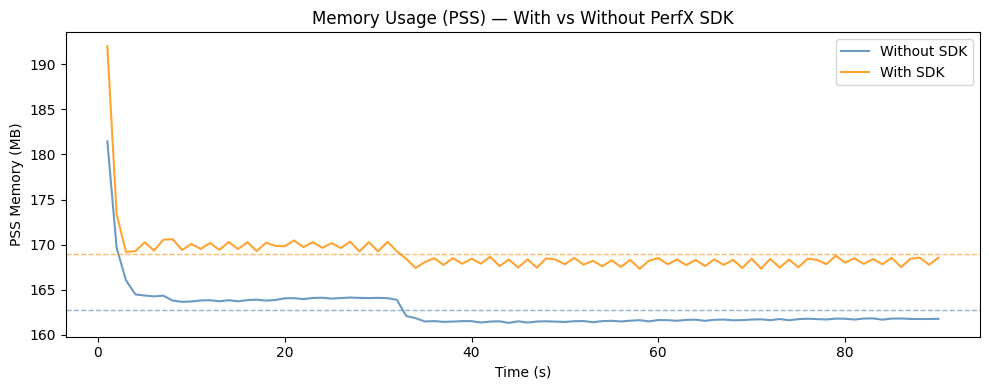

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(no_sdk.timestamp_s,   no_sdk.pss_mb,   label='Without SDK', color='steelblue',  alpha=0.8)
ax.plot(with_sdk.timestamp_s, with_sdk.pss_mb, label='With SDK',    color='darkorange', alpha=0.8)

ax.axhline(no_sdk.pss_mb.mean(),   color='steelblue',  linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(with_sdk.pss_mb.mean(), color='darkorange', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('Time (s)')
ax.set_ylabel('PSS Memory (MB)')
ax.set_title('Memory Usage (PSS) — With vs Without PerfX SDK')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS}/memory_overhead.png', dpi=150)
plt.show()

## 5. Startup time distribution

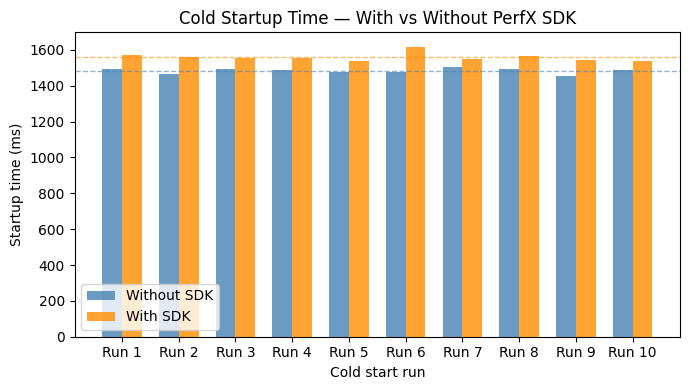

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

x     = np.arange(len(startup_no))
width = 0.35

ax.bar(x - width/2, startup_no.values,   width, label='Without SDK', color='steelblue',  alpha=0.8)
ax.bar(x + width/2, startup_with.values, width, label='With SDK',    color='darkorange', alpha=0.8)

ax.axhline(startup_no.mean(),   color='steelblue',  linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(startup_with.mean(), color='darkorange', linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('Cold start run')
ax.set_ylabel('Startup time (ms)')
ax.set_title('Cold Startup Time — With vs Without PerfX SDK')
ax.set_xticks(x)
ax.set_xticklabels([f'Run {i+1}' for i in x])
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS}/startup_overhead.png', dpi=150)
plt.show()

## 6. Combined bar chart (for thesis)

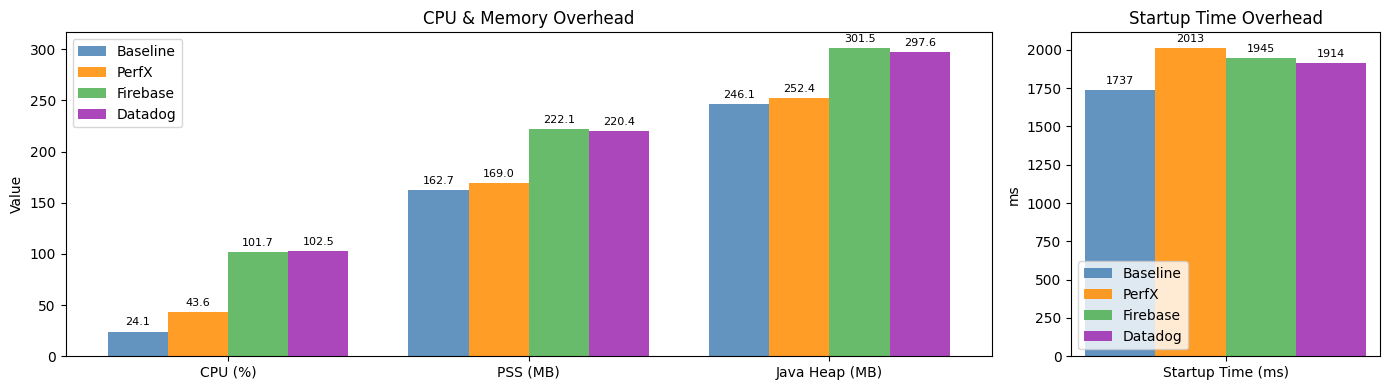

In [31]:
labels = ['Baseline', 'PerfX', 'Firebase', 'Datadog']
colors = ['steelblue', 'darkorange', '#4caf50', '#9c27b0']

metrics = ['CPU (%)', 'PSS (MB)', 'Java Heap (MB)', 'Startup Time (ms)']
no_vals    = [no_sdk.cpu_pct.mean(),   no_sdk.pss_mb.mean(),   no_sdk.java_heap_mb.mean(),   startup_no.mean()]
perfx_vals = [with_sdk.cpu_pct.mean(), with_sdk.pss_mb.mean(), with_sdk.java_heap_mb.mean(), startup_with.mean()]
fb_vals    = [with_fb.cpu_pct.mean(),  with_fb.pss_mb.mean(),  with_fb.java_heap_mb.mean(),  startup_fb.mean()]
dd_vals    = [with_dd.cpu_pct.mean(),  with_dd.pss_mb.mean(),  with_dd.java_heap_mb.mean(),  startup_dd.mean()]

x = np.arange(len(metrics))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 1]})

# Left: CPU, PSS, Java Heap
ax1 = axes[0]
b1 = ax1.bar(x[:3] - 1.5*width, no_vals[:3],    width, label='Baseline', color=colors[0], alpha=0.85)
b2 = ax1.bar(x[:3] - 0.5*width, perfx_vals[:3], width, label='PerfX',    color=colors[1], alpha=0.85)
b3 = ax1.bar(x[:3] + 0.5*width, fb_vals[:3],    width, label='Firebase', color=colors[2], alpha=0.85)
b4 = ax1.bar(x[:3] + 1.5*width, dd_vals[:3],    width, label='Datadog',  color=colors[3], alpha=0.85)
for b in (b1, b2, b3, b4):
    ax1.bar_label(b, fmt='%.1f', padding=3, fontsize=8)
ax1.set_xticks(x[:3])
ax1.set_xticklabels(metrics[:3])
ax1.set_ylabel('Value')
ax1.set_title('CPU & Memory Overhead')
ax1.legend()

# Right: Startup time
ax2 = axes[1]
sx = np.array([0])
b5 = ax2.bar(sx - 1.5*width, [no_vals[3]],    width, label='Baseline', color=colors[0], alpha=0.85)
b6 = ax2.bar(sx - 0.5*width, [perfx_vals[3]], width, label='PerfX',    color=colors[1], alpha=0.85)
b7 = ax2.bar(sx + 0.5*width, [fb_vals[3]],    width, label='Firebase', color=colors[2], alpha=0.85)
b8 = ax2.bar(sx + 1.5*width, [dd_vals[3]],    width, label='Datadog',  color=colors[3], alpha=0.85)
for b in (b5, b6, b7, b8):
    ax2.bar_label(b, fmt='%.0f', padding=3, fontsize=8)
ax2.set_xticks(sx)
ax2.set_xticklabels(['Startup Time (ms)'])
ax2.set_ylabel('ms')
ax2.set_title('Startup Time Overhead')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{RESULTS}/overhead_summary.png', dpi=150)
plt.show()